<a href="https://colab.research.google.com/github/howonJeong/Journey_to_TinyLLAMA/blob/main/Step1_MitDeep/1_6_NumericalDifferentiation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
def numerical_diff(f, x, h):
  return (f(x+h)-f(x))/h

In [2]:
np.float32(1e-50)
# 수치 미분에 활용하려면 작을 수록 좋지만 또 너무 적으면 반올림 오차

np.float32(0.0)

In [3]:
def function_1(x):
  return 0.01*(x**2) + 0.1

In [4]:
print(numerical_diff(function_1, 5, 1e-10))
print(numerical_diff(function_1, 5, 1e-15))

0.1000000082740371
0.11102230246251564


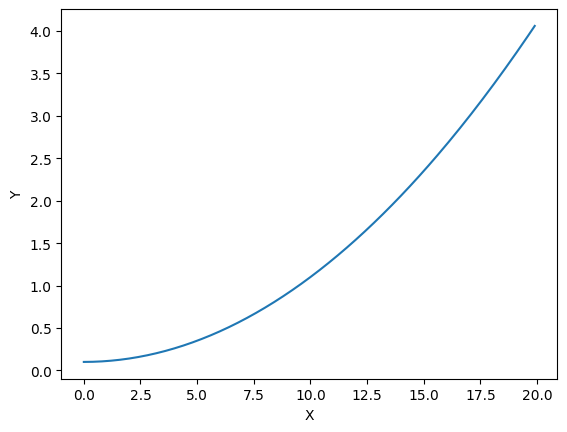

In [5]:
import matplotlib.pylab as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)
plt.xlabel("X")
plt.ylabel("Y")
plt.plot(x,y)
plt.show()

근사로 구한 접선 - x와 x+h를 잇는 a.k.a 전방 차분 - 은 오차가 크다.

x를 중심으로 전후의 차분을 계산하면 좀 오차가 줄어든다

>중심 차분, 중앙 차분

In [6]:
def numerical_diff_central(f,x):
  h = 1e-4
  return (f(x+h) - f(x-h)) / (2*h)

해석적 미분과 수치 미분

수치 미분은 아주 작은 차분, 그러나 무한대는 아닌 값으로 미분 하는 것을 수치 미분이라 한다.

반면 수식을 전개하여 미분을 하는 것을 해석적 미분, 해석적 해라 칭하며 진정한 미분 값을 오차 없이 구해낼 수 있다.

In [7]:
print(numerical_diff_central(function_1, 5))
print(numerical_diff(function_1, 5, 1e-4))

0.0999999999995449
0.10000099999962764


In [8]:
# 아래는 편미분

In [9]:
def function_2(x):
  return x[0]**2 + x[1] ** 2
#다변수 함수의 구현
#또는 return np.sum(x**2)

In [10]:
print(numerical_diff(function_2, np.array([5, 5]), 1e-10))

20.00000165480742


In [11]:
# xo = 3, x1 = 4일 때 x0에 대한 편미분은?
def function_temp1(x0):
  return x0 * x0 + 4.0 ** 2.0

numerical_diff(function_temp1, 3.0, 1e-10)

6.000000496442226

In [12]:
# 편미분의 핵심은 돌아가면서 미분하지 않을 변수들을 고정하는 것

def numerical_gradient(f, x):
  h = 1e-4
  grad = np.zeros_like(x)

  it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
  #인덱스를 저장하라는 플래그를 리스트에 담아 전달 + operand에게 읽기쓰기 모드를 원함 (기본은 읽기)
  while not it.finished:
    idx = it.multi_index

    tmp_val = x[idx]

    x[idx] = tmp_val + h
    fxh1 = f(x)

    x[idx] = tmp_val - h
    fxh2 = f(x)

    grad[idx] = (fxh1 - fxh2) / (2*h)

    x[idx] = tmp_val
    #여기서 복원하는 방식을 쓰는 이유

    it.iternext()

  return grad

기울기 절댓값은 극값에 가까워질수록 작아지기 때문에 학습률에 상관없이 천천히 수렴하게 함.

물론 학습률이 너무 크면 안되고..

기울기 자체의 정의는 함수값이 커지는 방향이기 때문에 그건 고려해야 한다.


In [13]:
import numpy as np

In [61]:
def gradient_descent(f, init_x, lr = 0.01, step_num = 100):
  x = init_x

  for i in range(step_num):
    grad = numerical_gradient(f, x)
    x -= grad * lr

  return x

In [62]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x= init_x, step_num = 100)

array([-0.39785867,  0.53047822])

In [77]:
init_x = np.array([-3.0, 4.0])
gradient_descent(function_2, init_x=init_x, lr = 1e-11, step_num = 100)

array([-2.99999999,  3.99999999])

In [69]:
# learning rate와 같이 학습에 의해서 바뀌는게 아닌 사람의 개입이 필요한 매개변수를 초매개변수 - HyperParameter라 칭함